In [1]:
#Purpose
#analysing rising sea level trends in the Pacific and assessing the projected impact on low-lying nations

#Importing Libraries
library(tidyverse)
library(ggplot2)
library(reshape2)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'reshape2' was built under R version 4.5.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [2]:
#Importing dataset and inspection
main_df <- read.csv("fixed_cleaned_Tuvalu_sea_level_clean.csv")
glimpse(main_df) #shows every column name and it's data type and preview of actual values. Used instead of head() and str().

Rows: 520
Columns: 6
$ Year         <int> 1977, 1977, 1978, 1978, 1978, 1978, 1978, 1978, 1978, 197…
$ Month        <int> 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 3, 5, 6…
$ Monthly_MSL  <dbl> 6.919, 6.875, 6.829, 6.887, 6.921, 7.011, 7.013, 7.029, 7…
$ Linear_Trend <dbl> 6.923, 6.924, 6.924, 6.924, 6.925, 6.925, 6.925, 6.926, 6…
$ High_Conf    <dbl> 6.961, 6.961, 6.962, 6.962, 6.962, 6.962, 6.963, 6.963, 6…
$ Low_Conf     <dbl> 6.886, 6.886, 6.886, 6.887, 6.887, 6.888, 6.888, 6.888, 6…


In [7]:
summary(main_df)

      Year          Month         Monthly_MSL     Linear_Trend  
 Min.   :1977   Min.   : 1.000   Min.   :6.576   Min.   :6.923  
 1st Qu.:1989   1st Qu.: 3.000   1st Qu.:6.967   1st Qu.:6.967  
 Median :2000   Median : 6.000   Median :7.016   Median :6.992  
 Mean   :2000   Mean   : 6.502   Mean   :7.000   Mean   :6.999  
 3rd Qu.:2011   3rd Qu.:10.000   3rd Qu.:7.055   3rd Qu.:7.035  
 Max.   :2023   Max.   :12.000   Max.   :7.184   Max.   :7.080  
   High_Conf        Low_Conf      Decimal_Year 
 Min.   :6.961   Min.   :6.886   Min.   :1978  
 1st Qu.:6.993   1st Qu.:6.940   1st Qu.:1990  
 Median :7.016   Median :6.969   Median :2001  
 Mean   :7.028   Mean   :6.971   Mean   :2001  
 3rd Qu.:7.062   3rd Qu.:7.007   3rd Qu.:2012  
 Max.   :7.117   Max.   :7.042   Max.   :2023  

In [6]:
#Step 3 Creating new column combining year and month for the numeric predictor needed for lm()
main_df$Decimal_Year <- main_df$Year + (main_df$Month - 1) / 12 #Formula: Year + (Month - 1) / 12
# subtract 1 from Month first to anchor January at 0

# This is necessary because the dataset has multiple rows per year (one per month).
# Using Year alone would treat all months in the same year as the same point in time,
# losing the continuous progression of time.
#Decimal_Year ensures lm() fits the
# regression line against a smooth, evenly-spaced timeline, giving a more
# accurate slope (sea level rise per year).

head(main_df$Decimal_Year) # Preview the new Decimal_Year column to make sure it calculated correctly

[1] 1977.833 1977.917 1978.000 1978.083 1978.167 1978.250

[1] "Scatterplot saved"


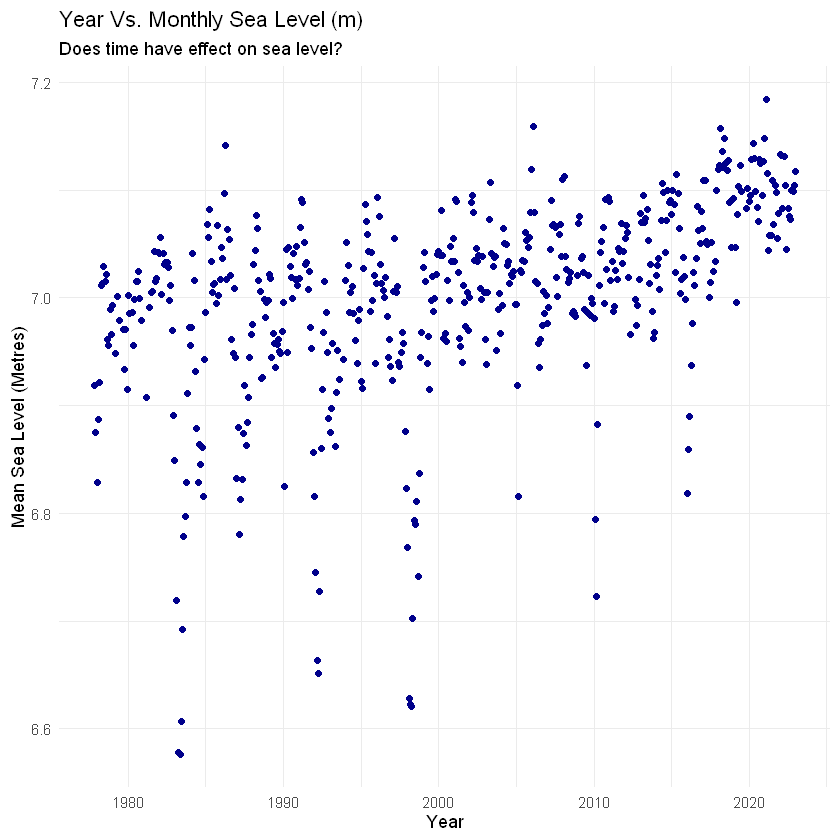

In [26]:
#Step 3.1 Visualising the scatterplot of Year vs Monthly_MSL
library(ggplot2)

ggplot(main_df, aes(x=Decimal_Year, y=Monthly_MSL)) +
      geom_point(color = "darkblue") +
      labs(
          title = "Year Vs. Monthly Sea Level (m)",
          subtitle = "Does time have effect on sea level?",
          y = "Mean Sea Level (Metres)",
          x = "Year"
          ) +
      theme_minimal()


ggsave("Tuvalu_year_vs_sea_level_scatterplot.png", width = 7, height = 5) #Exporting scatterplot into a png format
print("Scatterplot saved")

In [ ]:
#A visible trend from ~1977 to 2023
#Appears linear, sea level gradually rising over time. Regression is appropriate here

In [22]:
#Step 3.2 Fitting a linear regression model 
model <- lm(Monthly_MSL ~ Decimal_Year, data = main_df)
summary(model)


Call:
lm(formula = Monthly_MSL ~ Decimal_Year, data = main_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.37050 -0.03115  0.01406  0.05300  0.18898 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.4168280  0.5639786   0.739     0.46    
Decimal_Year 0.0032902  0.0002819  11.672   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.08276 on 518 degrees of freedom
Multiple R-squared:  0.2082,	Adjusted R-squared:  0.2067 
F-statistic: 136.2 on 1 and 518 DF,  p-value: < 2.2e-16


In [ ]:
#Step 3.3 Examining the Key Outputs
slope <- 0.0032902 #Each year there's an increase of mean sea level by approximately 3.3mm 
intercept <-  0.4168280 #Not meaningful on it's own
p_value <- 0.00000000000000022 #The slope is statistically significant, signfying that the upward trend is not due to random fluctuation in the data
adjusted_r_square <- 0.2067 # Year explains about 21% of variance in sea level. It's low but as the website says, the data doesn't take into consideration of
#regular seasonal fluctuations due to coastal ocean temperatures,salinities, winds, atmospheric pressures, and ocean currents.

std_error_intercept <- 0.5639786 #Has no real-world meaning for this dataset 
std_error_decimal_year <- 0.0002819 #3.3mm/year rise estimate is quite precise as the uncertainty is below the actual slope
residual_standard_error <- 0.08276 # monthly sea level observations deviate from the trend line by about ±82.76mm.

`geom_smooth()` using
formula = 'y ~ x'
`geom_smooth()` using
formula = 'y ~ x'


[1] "Scatterplot saved"


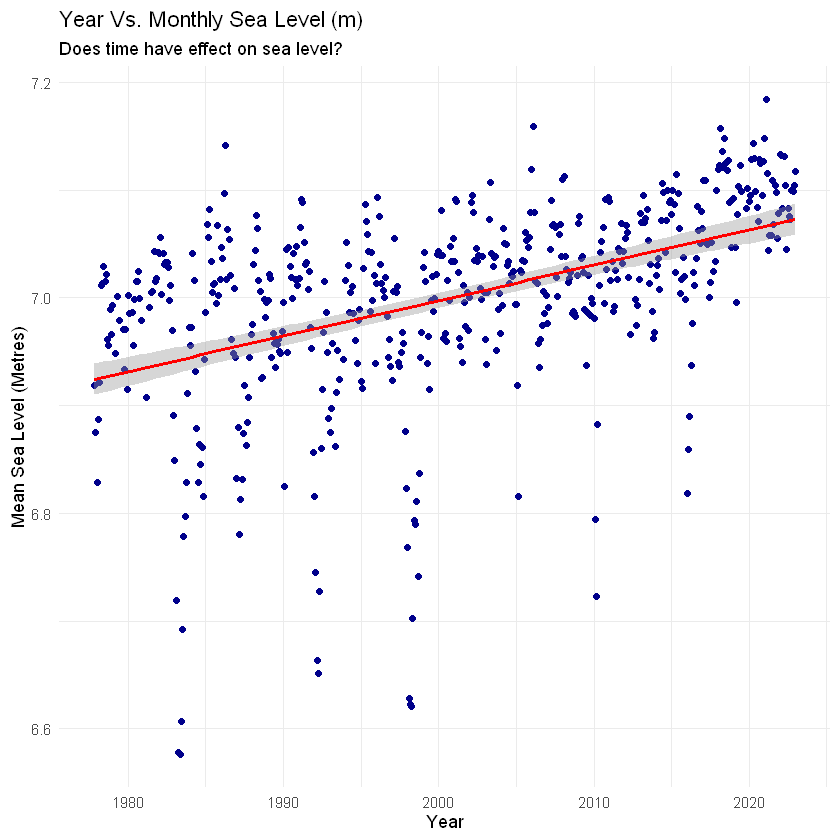

In [29]:
#Step 3.4 Adding a linear regression line into the scatterplot
library(ggplot2)

ggplot(main_df, aes(x=Decimal_Year, y=Monthly_MSL)) +
      geom_point(color = "darkblue") +
         geom_smooth(method = "lm", se = TRUE, color = "red") +
      labs(
          title = "Year Vs. Monthly Sea Level (m)",
          subtitle = "Does time have effect on sea level?",
          y = "Mean Sea Level (Metres)",
          x = "Year"
          ) +
      theme_minimal()


ggsave("Tuvalu_year_vs_sea_level_scatterplot_with_regression.png", width = 7, height = 5) #Exporting scatterplot into a png format
print("Scatterplot saved")

In [ ]:
#Step 3.5 The confidence levels 
# geom_smooth(se = TRUE) displays the 95% confidence interval as a shaded band
# around the regression line. This visualises the uncertainty in the position
# of the line itself — the narrower the band, the more precisely the model
# estimates the true trend. The band widens at the edges (early 1980s and 2020s)
# where data is sparser, indicating greater uncertainty in those periods.